# Homework 2 : Regression

**Auteur :** Anis-Samy Laamri
**Date :** October 2026

Dataset : *car fuel efficiency* https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

In [79]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

---
## Introduction : Dataset and preparing the dataset.

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg').

In [123]:
#Getting the data
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


---
### Use only the following columns:

'engine_displacement', <br>
'horsepower',<br>
'vehicle_weight',<br>
'model_year',<br>
'fuel_efficiency_mpg'<br>

In [61]:
df = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


---
### EDA:
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

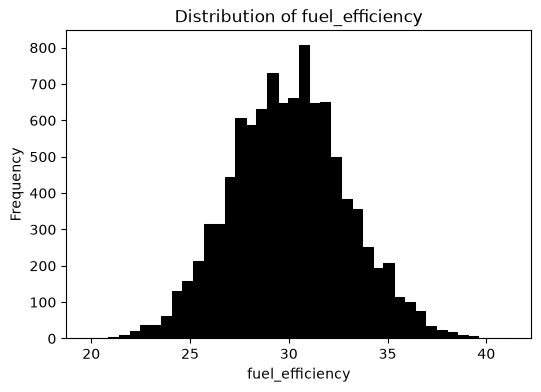

In [6]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg, bins=40, color='black', alpha=1) #Bins equals to the number of bars in the plotgraph
plt.ylabel('Frequency')
plt.xlabel('fuel_efficiency')
plt.title('Distribution of fuel_efficiency')

plt.show()

### No, the data collection doesn't seem to have a long tail

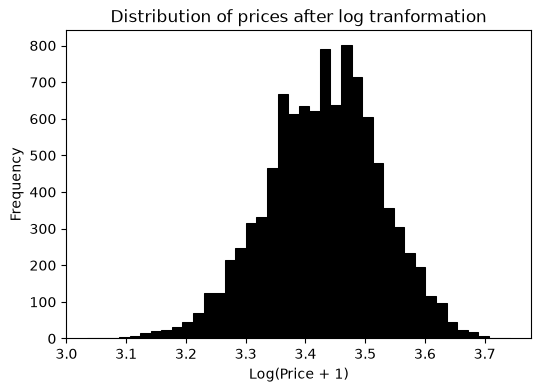

In [5]:
log_eff = np.log1p(df.fuel_efficiency_mpg) #Using the log to reduce the tail value,+1 to every value in array

plt.figure(figsize=(6, 4))

sns.histplot(log_eff, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Log(fuel_efficiency + 1)')
plt.title('Distribution of Fuel efficiency after log tranformation')

plt.show()
#Follow a normal distribution'

---
## Question 1 : There's one column with missing values. What is it?

'engine_displacement'
'horsepower'
'vehicle_weight'
'model_year'

In [9]:
#Q2
df.isnull().any()

engine_displacement    False
horsepower              True
vehicle_weight         False
model_year             False
fuel_efficiency_mpg    False
dtype: bool

### Horsepower is the column with missing values

---
## Question 2 : What's the median (50% percentile) for variable 'horsepower'?

204
254
304
354

In [55]:
#Q4 : Missing values How many columns in the dataset have missing values?
df.describe(include="all")
mean = df['horsepower'].mean()

### The median for variable 'horsepower' is 254

---
### Prepare and split the dataset:

Shuffle the filtered dataset and create the split exactly as in the lecture:

In [112]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [142]:
y_train_orig = df_train.fuel_efficiency_mpg.values
y_val_orig = df_val.fuel_efficiency_mpg.values
y_test_orig = df_test.fuel_efficiency_mpg.values

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

---
## Question 3 : 

We need to deal with missing values for the column from Q1. <br>
We have two options: fill it with 0 or with the mean of this variable.<br>
Try both options. For each, train a linear regression model without regularization using the code from the lessons. <br>
For computing the mean, use the training only! <br>
Use the validation dataset to evaluate the models and compare the RMSE of each option. <br>
Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release. <br>
Which option gives better RMSE? <br>

In [143]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [144]:
base = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',]

In [145]:
def prepare_X(df,val):
    df_num = df[base]
    df_num = df_num.fillna(val)
    X = df_num.values
    return X

In [146]:
X_train = prepare_X(df_train,0)
w_0, w = train_linear_regression(X_train, y_train)

In [147]:
y_pred = w_0 + X_train.dot(w)

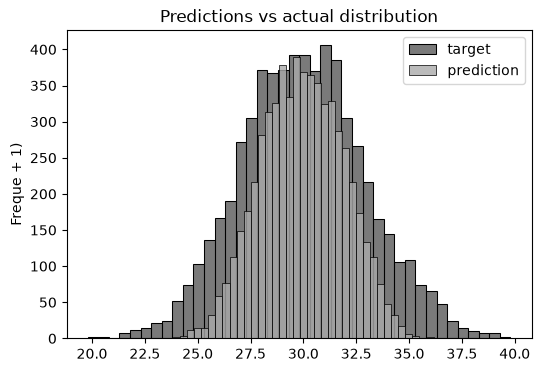

In [148]:
#Q3 First option : fill missing value for the column is 0
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Freque + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

In [149]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [150]:
print("RMSE avec 0 :", round(rmse(y_train, y_pred), 3))

RMSE avec 0 : 2.2


In [151]:
#Q3 Second option : fill missing value for the column is the mean
X_train = prepare_X(df_train,mean)
w_0, w = train_linear_regression(X_train, y_train)

In [152]:
y_pred = w_0 + X_train.dot(w)

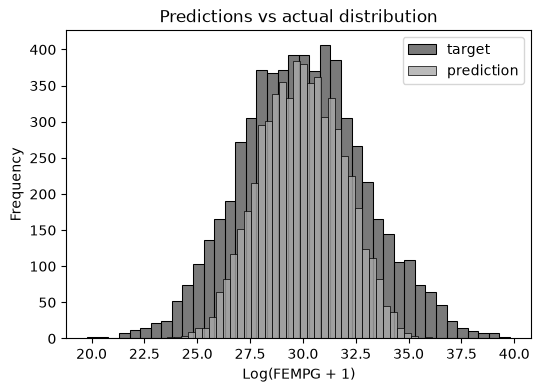

In [153]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(FEMPG + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

In [154]:
print("RMSE avec mean :", round(rmse(y_train, y_pred), 3))

RMSE avec mean : 2.199


---
## Question 4 : Regular linear regression

Now let's train a regularized linear regression. <br>
For this question, fill the NAs with 0.<br>
Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].<br>
Use RMSE to evaluate the model on the validation dataset.<br>
Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.<br>
Which r gives the best RMSE?<br>

If multiple options give the same best RMSE, select the smallest r.

Options:

0
0.01
0.1
1
5
10
100

In [155]:
#Q4 
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [156]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print(r, round(score, 4))

0 2.207
0.01 2.2067
0.1 2.2195
1 2.3364
5 2.3952
10 2.4051
100 2.4146


---
## Question 5 : Change of seed number

We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.<br>
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].<br>
For each seed, do the train/validation/test split with 60%/20%/20% distribution.<br>
Fill the missing values with 0 and train a model without regularization.<br>
For each seed, evaluate the model on the validation dataset and collect the RMSE scores.<br>
What's the standard deviation of all the scores? To compute the standard deviation, use np.std.<br>
Round the result to 3 decimal digits (round(std, 3))<br>
What's the value of std?<br>

0.006
0.016
0.029
0.036<br>
Note: Standard deviation shows how different the values are. If it's low, then all values are approximately the same. If it's high, the values are different. If standard deviation of scores is low, then our model is stable.

In [157]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    # Découpage 60 / 20 / 20
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx]
    df_train = df_shuffled.iloc[:n_train].reset_index(drop=True)
    df_val = df_shuffled.iloc[n_train:n_train + n_val].reset_index(drop=True)
    df_test = df_shuffled.iloc[n_train + n_val:].reset_index(drop=True)

    # Variable cible : 
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    # Remplissage par 0, régression sans régularisation
    X_train = prepare_X(df_train, 0)
    X_val = prepare_X(df_val, 0)

    w_0, w = train_linear_regression(X_train, y_train)
    y_pred = w_0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)
    print(seed, round(score,3))

std = np.std(scores)
print("Écart-type :", round(std, 3))

0 2.239
1 2.202
2 2.163
3 2.204
4 2.202
5 2.246
6 2.27
7 2.191
8 2.217
9 2.207
Écart-type : 0.029


---
## Question  : Sum of weight

Split the dataset like previously, use seed 9. <br>
Combine train and validation datasets. <br>
Fill the missing values with 0 and train a model with r=0.001. <br>
What's the RMSE on the test dataset? <br>
Options: <br>

0.236
2.236
22.10
221.0


In [ ]:
# Découpage 60 / 20 / 20
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(9)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx]
    df_train = df_shuffled.iloc[:n_train].reset_index(drop=True)
    df_val = df_shuffled.iloc[n_train:n_train + n_val].reset_index(drop=True)
    df_test = df_shuffled.iloc[n_train + n_val:].reset_index(drop=True)

# Fusion train + validation
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

    # Variable cible : 
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    # Remplissage par 0, régression sans régularisation
    X_train = prepare_X(df_train, 0)
    X_val = prepare_X(df_val, 0)

    w_0, w = train_linear_regression(X_train, y_train)
    y_pred = w_0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)
    print(seed, round(score,3))